In [74]:
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
import pandas as pd
import numpy as np
import torch
import os 
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [34]:
from dotenv import load_dotenv
load_dotenv()

True

In [35]:
dataset_dir = os.getenv("DATASET_DIR")
datasplit_dir = os.getenv("DATASPLITS_DIR")

train_path = os.path.join(datasplit_dir, "mm_train.tsv")
test_path = os.path.join(datasplit_dir, "mm_test.tsv")
val_path = os.path.join(datasplit_dir, "mm_val.tsv")

In [36]:
df_train = pd.read_csv(train_path, sep = "\t")
df_test = pd.read_csv(test_path, sep = "\t")
df_val = pd.read_csv(val_path, sep = "\t")

print(df_train.shape)
print(df_train.columns)


(9911, 4)
Index(['cleaned_tweet_text', 'image_path', 'mm_info', 'mm_human'], dtype='object')


In [37]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [38]:
def extract_roberta_embeddings(df, text_column="tweet_text", model_name="roberta-base", batch_size=32):
    """
    Estrae gli embedding [CLS] da RoBERTa per una colonna testuale in un DataFrame.

    Args:
        df (pd.DataFrame): DataFrame contenente la colonna del testo.
        text_column (str): Nome della colonna che contiene il testo.
        model_name (str): Nome del modello Hugging Face (es. "roberta-base").
        batch_size (int): Dimensione del batch per l'elaborazione.
        device (str): "cuda" o "cpu". Se None, viene usato automaticamente.

    Returns:
        pd.DataFrame: DataFrame con un embedding per riga (shape: len(df) × hidden_dim)
    """

    # Carica tokenizer e modello
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.to(device)
    model.eval()

    all_embeddings = []

    # Elaborazione a batch
    texts = df[text_column].tolist()
    for i in tqdm(range(0, len(texts), batch_size), desc="Extracting embeddings"):
        batch_texts = texts[i:i+batch_size]
        encodings = tokenizer(batch_texts, padding=True, truncation=True, return_tensors="pt", max_length=128)
        encodings = {k: v.to(device) for k, v in encodings.items()}

        with torch.no_grad():
            outputs = model(**encodings)
            cls_embeddings = outputs.last_hidden_state[:, 0, :]  # [CLS] token
            all_embeddings.append(cls_embeddings.cpu().numpy())

    # Concatena tutti gli embeddings
    all_embeddings = np.concatenate(all_embeddings, axis=0)
    emb_df = pd.DataFrame(all_embeddings)
    emb_df.index = df.index  # mantiene gli stessi indici del df originale
    return emb_df


In [39]:
# Esempio d’uso

df_train_text_embeddings = extract_roberta_embeddings(df=df_train, text_column="cleaned_tweet_text", model_name="roberta-base")
df_val_text_embeddings = extract_roberta_embeddings(df=df_val, text_column="cleaned_tweet_text", model_name="roberta-base")
df_test_text_embeddings = extract_roberta_embeddings(df=df_test, text_column="cleaned_tweet_text", model_name="roberta-base")

df_train_text_embeddings.shape

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Extracting embeddings: 100%|██████████| 310/310 [00:21<00:00, 14.10it/s]
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Extracting embeddings: 100%|██████████| 105/105 [00:08<00:00, 12.86it/s]
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Extracting embeddings: 100%|█

(9911, 768)

In [40]:
def extract_efficientnet_embeddings(df, image_column="image_path", target_size=(224, 224), batch_size=32):
    """
    Estrae gli embedding dalle immagini usando EfficientNetB0 (senza classification head).

    Args:
        df (pd.DataFrame): DataFrame contenente i path alle immagini.
        image_column (str): Nome della colonna con i path immagine.
        target_size (tuple): Dimensione a cui ridimensionare le immagini.
        batch_size (int): Batch size per l’elaborazione.

    Returns:
        pd.DataFrame: DataFrame con un embedding per immagine.
    """
    # Carica EfficientNet senza top
    base_model = EfficientNetB0(include_top=False, weights='imagenet', pooling='avg')
    model = Model(inputs=base_model.input, outputs=base_model.output)

    embeddings = []

    paths = df[image_column].tolist()
    for i in tqdm(range(0, len(paths), batch_size), desc="Extracting image embeddings"):
        batch_paths = paths[i:i+batch_size]
        batch_images = []

        for path in batch_paths:
            try:
                img = image.load_img(path, target_size=target_size)
                img_array = image.img_to_array(img)
                img_array = preprocess_input(img_array)
                batch_images.append(img_array)
            except Exception as e:
                print(f"Errore con immagine {path}: {e}")
                batch_images.append(np.zeros((*target_size, 3)))  # fallback neutro

        batch_images = np.array(batch_images)
        batch_emb = model.predict(batch_images, verbose=0)
        embeddings.append(batch_emb)

    all_embeddings = np.concatenate(embeddings, axis=0)
    emb_df = pd.DataFrame(all_embeddings)
    emb_df.index = df.index
    return emb_df


In [41]:
df_train_img_embeddings = extract_efficientnet_embeddings(df=df_train, image_column="image_path")
df_val_img_embeddings = extract_efficientnet_embeddings(df=df_val, image_column="image_path")
df_test_img_embeddings = extract_efficientnet_embeddings(df=df_test, image_column="image_path")

df_train_img_embeddings.shape

Extracting image embeddings:  25%|██▍       | 77/310 [00:50<02:27,  1.58it/s]c:\Users\mario\Desktop\Deep Learning\Progetto\multimodal-crisis-classification\deep_env2\lib\site-packages\PIL\Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Extracting image embeddings: 100%|██████████| 106/106 [01:11<00:00,  1.48it/s]


(9911, 1280)

In [43]:
# Per usarli in fusion:
combined_train = np.concatenate([df_train_text_embeddings.to_numpy(), df_train_img_embeddings.to_numpy()], axis=1)
combined_val = np.concatenate([df_val_text_embeddings.to_numpy(), df_val_img_embeddings.to_numpy()], axis=1)
combined_test = np.concatenate([df_test_text_embeddings.to_numpy(), df_test_img_embeddings.to_numpy()], axis=1)

combined_train.shape

(9911, 2048)

In [79]:
le_info = LabelEncoder()
y_train_task1 = le_info.fit_transform(df_train["mm_info"])
y_val_task1 = le_info.transform(df_val["mm_info"])
y_test_task1 = le_info.transform(df_test["mm_info"])

# Task 2
le_human = LabelEncoder()
y_train_task2 = le_human.fit_transform(df_train["mm_human"])
y_val_task2 = le_human.transform(df_val["mm_human"])
y_test_task2 = le_human.transform(df_test["mm_human"])

In [54]:
def build_multitask_fusion_model(input_dim, num_classes_task2, learning_rate=1e-3, dropout_rate=0.4):
    """
    Costruisce e restituisce un modello multitask con early fusion (testo + immagine)
    e due teste di classificazione: binaria (task1) e multiclasse (task2).

    Args:
        input_dim (int): Dimensione totale dell’input (text_emb + img_emb).
        num_classes_task2 (int): Numero di classi per il secondo task.
        learning_rate (float): Learning rate dell’ottimizzatore.
        dropout_rate (float): Dropout tra i layer fully connected.

    Returns:
        model (tf.keras.Model): Il modello compilato.
        early_stopping (tf.keras.callbacks.EarlyStopping): Callback già pronto.
    """

    # Input combinato
    fusion_input = Input(shape=(input_dim,), name="fusion_input")

    # Shared layers
    x = Dense(256, activation='relu')(fusion_input)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)

    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(dropout_rate)(x)

    # Head 1 - binary (task 1)
    task1_out = Dense(1, activation='sigmoid', name="task1_output")(x)

    # Head 2 - multiclass (task 2)
    task2_out = Dense(num_classes_task2, activation='softmax', name="task2_output")(x)

    # Build model
    model = Model(inputs=fusion_input, outputs=[task1_out, task2_out])

    # Compile
    model.compile(
        optimizer=Adam(learning_rate),
        loss={
            "task1_output": "binary_crossentropy",
            "task2_output": "sparse_categorical_crossentropy"
        },
        metrics={
            "task1_output": ["accuracy"],
            "task2_output": ["accuracy"]
        }
    )

    return model


In [69]:
def plot_training_history_multitask(history, title="Multitask Training"):
    """
    Plot accuracy and loss curves for each task (training and validation).
    """
    epochs = range(1, len(history.history['loss']) + 1)

    plt.figure(figsize=(16, 6))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['loss'], label='Total Train Loss')
    plt.plot(epochs, history.history['val_loss'], label='Total Val Loss')
    plt.plot(epochs, history.history['task1_output_loss'], '--', label='Task 1 Train Loss')
    plt.plot(epochs, history.history['val_task1_output_loss'], '--', label='Task 1 Val Loss')
    plt.plot(epochs, history.history['task2_output_loss'], '--', label='Task 2 Train Loss')
    plt.plot(epochs, history.history['val_task2_output_loss'], '--', label='Task 2 Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['task1_output_accuracy'], label='Task 1 Train Acc')
    plt.plot(epochs, history.history['val_task1_output_accuracy'], label='Task 1 Val Acc')
    plt.plot(epochs, history.history['task2_output_accuracy'], label='Task 2 Train Acc')
    plt.plot(epochs, history.history['val_task2_output_accuracy'], label='Task 2 Val Acc')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


In [81]:
def evaluate_multitask_model(model, X_test, y_test_task1, y_test_task2, label_encoder_task1=None, label_encoder_task2=None):
    """
    Valuta un modello multitask su entrambi i task e stampa:
    - Accuracy, Precision, Recall, F1
    - Matrice di confusione
    """
    # Predizioni
    y_pred_task1, y_pred_task2 = model.predict(X_test)

    # Task 1 (binario)
    y_pred_task1_cls = (y_pred_task1 > 0.5).astype(int)

    print("\n📊 Task 1 - Informative vs Not Informative")
    print("Accuracy :", accuracy_score(y_test_task1, y_pred_task1_cls))
    print("Precision:", precision_score(y_test_task1, y_pred_task1_cls))
    print("Recall   :", recall_score(y_test_task1, y_pred_task1_cls))
    print("F1-score :", f1_score(y_test_task1, y_pred_task1_cls))

    cm1 = confusion_matrix(y_test_task1, y_pred_task1_cls)
    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=label_encoder_task1.classes_ if label_encoder_task1 else None)
    disp1.plot(cmap='Blues')
    plt.title("Task 1 - Confusion Matrix")
    plt.show()

    # Task 2 (multiclasse)
    y_pred_task2_cls = np.argmax(y_pred_task2, axis=1)

    print("\n📊 Task 2 - Humanitarian Categories")
    print("Accuracy :", accuracy_score(y_test_task2, y_pred_task2_cls))
    print("Precision:", precision_score(y_test_task2, y_pred_task2_cls, average='macro'))
    print("Recall   :", recall_score(y_test_task2, y_pred_task2_cls, average='macro'))
    print("F1-score :", f1_score(y_test_task2, y_pred_task2_cls, average='macro'))

    cm2 = confusion_matrix(y_test_task2, y_pred_task2_cls)
    disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=label_encoder_task2.classes_ if label_encoder_task2 else None)
    disp2.plot(cmap='Blues', xticks_rotation=45)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.title("Task 2 - Confusion Matrix")
    plt.show()


In [59]:
# Costruzione del modello
input_dim = combined_train.shape[1]
num_classes_task2 = len(np.unique(y_train_task2))

model = build_multitask_fusion_model(input_dim, num_classes_task2)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Training
history = model.fit(
    x=combined_train,
    y={
        "task1_output": y_train_task1,
        "task2_output": y_train_task2
    },
    validation_data=(
        combined_val,
        {
            "task1_output": y_val_task1,
            "task2_output": y_val_task2
        }
    ),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 2.4082 - task1_output_accuracy: 0.6527 - task1_output_loss: 0.7146 - task2_output_accuracy: 0.4193 - task2_output_loss: 1.6937 - val_loss: 1.4062 - val_task1_output_accuracy: 0.8116 - val_task1_output_loss: 0.4077 - val_task2_output_accuracy: 0.6220 - val_task2_output_loss: 0.9986
Epoch 2/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.5555 - task1_output_accuracy: 0.7929 - task1_output_loss: 0.4465 - task2_output_accuracy: 0.5875 - task2_output_loss: 1.1090 - val_loss: 1.2933 - val_task1_output_accuracy: 0.8387 - val_task1_output_loss: 0.3652 - val_task2_output_accuracy: 0.6494 - val_task2_output_loss: 0.9280
Epoch 3/20
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.3528 - task1_output_accuracy: 0.8253 - task1_output_loss: 0.3881 - task2_output_accuracy: 0.6356 - task2_output_loss: 0.9647 - val_loss: 1.2578 - val_task1_output_accuracy: 0.8411 - val_task1_output_loss: 0.3578 - val_task2_output_accuracy: 0.6613 - val_

dict_keys(['loss', 'task1_output_accuracy', 'task1_output_loss', 'task2_output_accuracy', 'task2_output_loss', 'val_loss', 'val_task1_output_accuracy', 'val_task1_output_loss', 'val_task2_output_accuracy', 'val_task2_output_loss'])


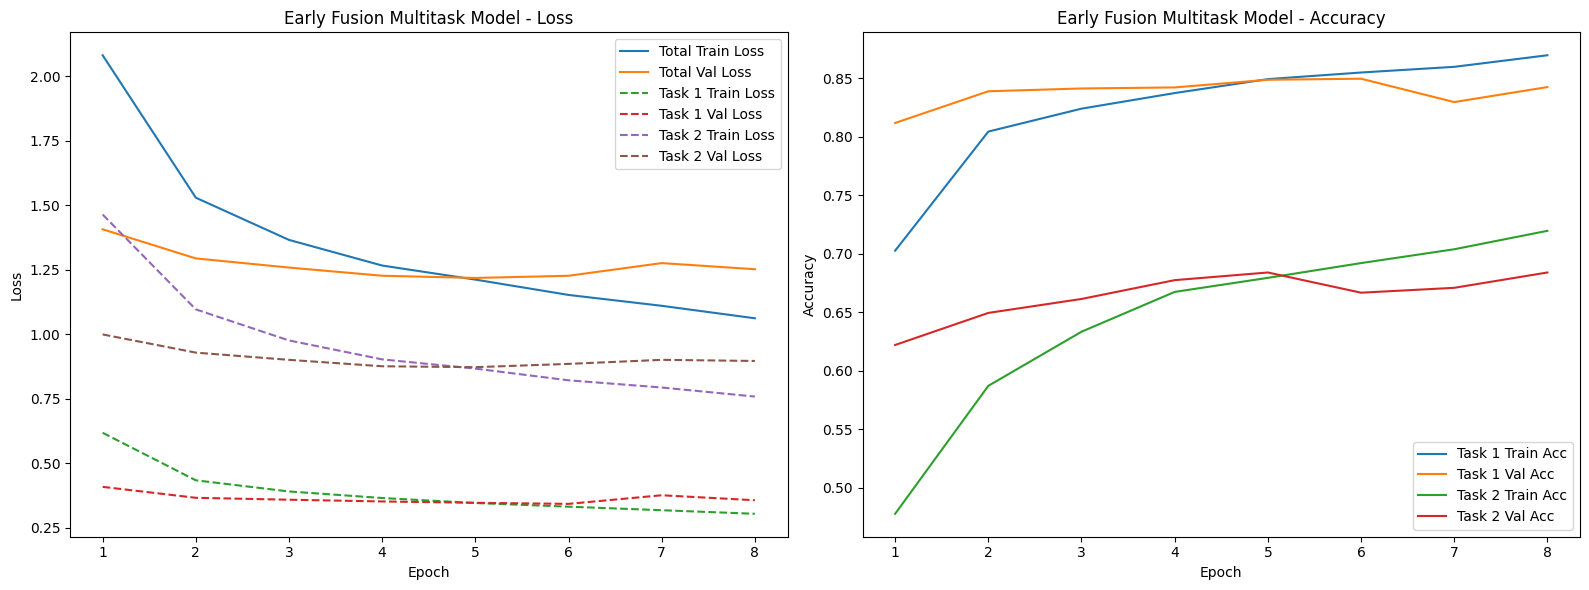

In [73]:
print(history.history.keys())
plot_training_history_multitask(history, title="Early Fusion Multitask Model")

106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

📊 Task 1 - Informative vs Not Informative
Accuracy : 0.8378458792026182
Precision: 0.7142857142857143
Recall   : 0.6177829099307159
F1-score : 0.6625386996904025


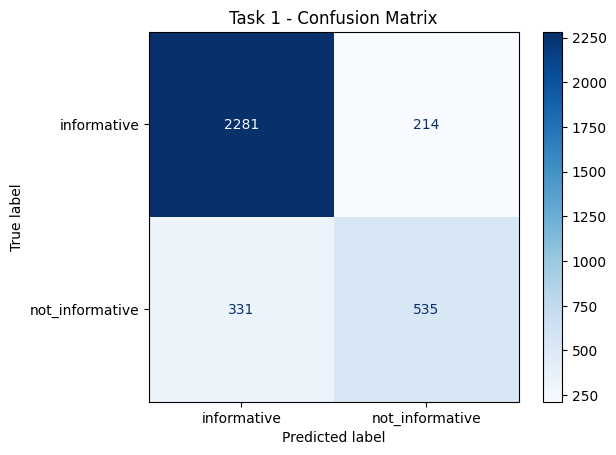


📊 Task 2 - Humanitarian Categories
Accuracy : 0.677774471883368
Precision: 0.6568622344646754
Recall   : 0.5986939760403323
F1-score : 0.6041040946570836


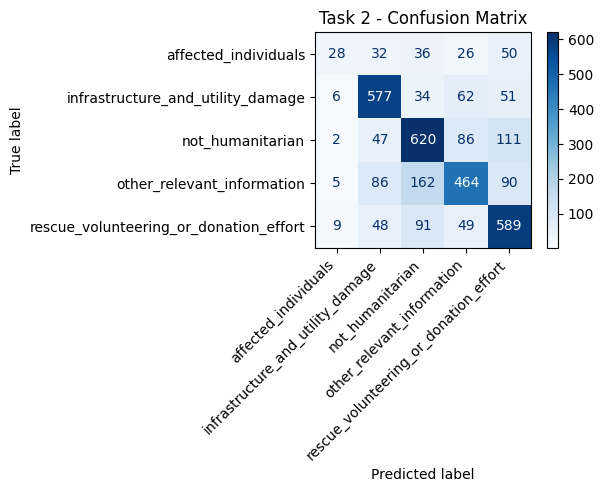

In [82]:
evaluate_multitask_model(
    model=model,
    X_test=combined_test,
    y_test_task1=y_test_task1,
    y_test_task2=y_test_task2,
    label_encoder_task1=le_info,
    label_encoder_task2=le_human
)